100%|██████████| 704/704 [00:12<00:00, 58.41it/s]


Epoch 1/20 | Train Loss: 4.0752 | Val Loss: 3.2922


100%|██████████| 704/704 [00:11<00:00, 61.66it/s]


Epoch 2/20 | Train Loss: 2.9835 | Val Loss: 2.7675


100%|██████████| 704/704 [00:12<00:00, 57.81it/s]


...

Epoch 18/20 | Train Loss: 0.6130 | Val Loss: 1.3312


100%|██████████| 704/704 [00:11<00:00, 60.58it/s]


Epoch 19/20 | Train Loss: 0.5615 | Val Loss: 1.3244


100%|██████████| 704/704 [00:11<00:00, 60.63it/s]


Epoch 20/20 | Train Loss: 0.5145 | Val Loss: 1.3293


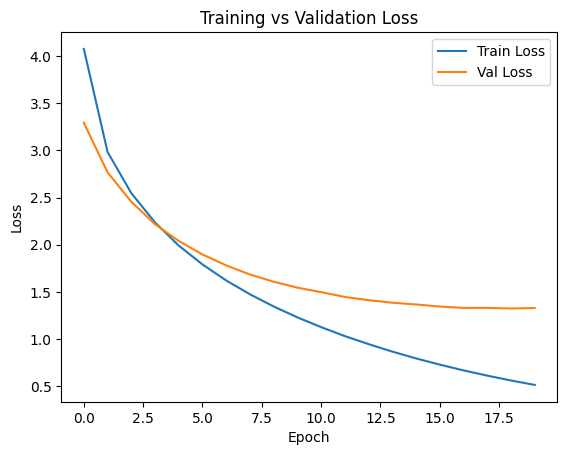


--- SAMPLE TRANSLATIONS ---

EN: Help yourself to more cookies.
ES (target): Sírvete más galletas.
ES (pred):   ▁[ end ▁[ end ▁puede ▁puede ▁puede ▁puede ▁puede ▁puede ▁puede ▁puede ▁puede ▁puede ▁puede ▁puede ▁puede ▁puede ▁puede

EN: Rabbits breed quickly.
ES (target): Los conejos se reproducen rapidamente.
ES (pred):   ▁[ end end end end end end end end end end end end end end end end end end

EN: That's them.
ES (target): Ahí están.
ES (pred):   ▁[ end end end end end end end end end end end end end end end end end end

EN: The solution was quite simple.
ES (target): La solución era muy simple.
ES (pred):   ▁[ end end end end end end end end end end end end end end end end end end

EN: I need medical assistance.
ES (target): Necesito asistencia médica.
ES (pred):   ▁[ end ▁[ end ▁[ end ▁[ end ▁[ end ▁[ end ▁[ end ▁[ end ▁[ end ▁[



In [ ]:

!pip install datasets sentencepiece==0.1.99 matplotlib torchtext --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
import sentencepiece as spm
import re
import random
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load Dataset (50k only)

dataset = load_dataset("OscarNav/spa-eng")
dataset = dataset["train"]
dataset = dataset.select(range(50000))   # limit to 50k


# Preprocessing Functions (Lowercase + Remove Punct)

def clean_text(t):
    t = t.lower()
    t = re.sub(r"[^a-zA-Záéíóúüñ¿¡ ]+", "", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

# Prepare Dataset for SentencePiece Tokenizer

with open("eng.txt", "w", encoding="utf-8") as f1, open("spa.txt", "w", encoding="utf-8") as f2:
    for row in dataset:
        f1.write(clean_text(row['eng']) + "\n")
        f2.write("[start] " + clean_text(row['spa']) + " [end]\n")

# Train SentencePiece Tokenizers (15k vocab)

spm.SentencePieceTrainer.train(
    input='eng.txt',
    model_prefix='eng',
    vocab_size=7687, # Changed from 15000 to 7687
    character_coverage=1.0
)

spm.SentencePieceTrainer.train(
    input='spa.txt',
    model_prefix='spa',
    vocab_size=7687, # Changed from 15000 to 7687
    character_coverage=1.0
)

# Load Tokenizers

eng_sp = spm.SentencePieceProcessor()
spa_sp = spm.SentencePieceProcessor()
eng_sp.load("eng.model")
spa_sp.load("spa.model")

PAD_ID = 0
MAX_LEN = 20


# PyTorch Dataset Class

class TranslationDataset(Dataset):
    def __init__(self, ds):
        self.data = ds

    def __len__(self):
        return len(self.data)

    def encode(self, sp, text):
        ids = sp.encode(text)
        if len(ids) > MAX_LEN:
            ids = ids[:MAX_LEN]
        ids = ids + [PAD_ID] * (MAX_LEN - len(ids))
        return torch.tensor(ids)

    def __getitem__(self, idx):
        item = self.data[idx]
        en = clean_text(item['eng'])
        es = "[start] " + clean_text(item['spa']) + " [end]"

        x = self.encode(eng_sp, en)
        y = self.encode(spa_sp, es)

        return x, y


# Create Train/Test Split + Dataloaders


data = list(dataset)
random.shuffle(data)

split = int(0.9 * len(data))
train_data = TranslationDataset(data[:split])
val_data   = TranslationDataset(data[split:])

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=64)


# Multi-Head Attention (Custom Cross-Attention)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=256, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.dk = d_model // num_heads

        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)

    def forward(self, q, k, v):
        B, Lq, _ = q.size()
        _, Lk, _ = k.size()

        Q = self.Wq(q).reshape(B, Lq, self.num_heads, self.dk).transpose(1, 2)
        K = self.Wk(k).reshape(B, Lk, self.num_heads, self.dk).transpose(1, 2)
        V = self.Wv(v).reshape(B, Lk, self.num_heads, self.dk).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-1, -2)) / (self.dk ** 0.5)
        attn = torch.softmax(scores, dim=-1)

        out = torch.matmul(attn, V)
        out = out.transpose(1, 2).reshape(B, Lq, self.d_model)

        return self.out(out)


# Feed Forward Layer

class FeedForward(nn.Module):
    def __init__(self, d_model=256, dim_ff=1024):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, dim_ff),
            nn.ReLU(),
            nn.Linear(dim_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

# Encoder Block

class EncoderLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.self_attn = MultiHeadAttention()
        self.ff = FeedForward()
        self.norm1 = nn.LayerNorm(256)
        self.norm2 = nn.LayerNorm(256)

    def forward(self, x):
        attn = self.self_attn(x, x, x)
        x = self.norm1(x + attn)
        ff = self.ff(x)
        x = self.norm2(x + ff)
        return x


# Encoder

class Encoder(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, 256)
        self.layer = EncoderLayer()

    def forward(self, x):
        x = self.embed(x)
        return self.layer(x)


# Decoder Block with Cross-Attention

class DecoderLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.self_attn = MultiHeadAttention()
        self.cross_attn = MultiHeadAttention()
        self.ff = FeedForward()

        self.norm1 = nn.LayerNorm(256)
        self.norm2 = nn.LayerNorm(256)
        self.norm3 = nn.LayerNorm(256)

    def forward(self, x, enc_out):
        self_attn = self.self_attn(x, x, x)
        x = self.norm1(x + self_attn)

        cross = self.cross_attn(x, enc_out, enc_out)
        x = self.norm2(x + cross)

        ff = self.ff(x)
        x = self.norm3(x + ff)
        return x

# Decoder

class Decoder(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, 256)
        self.layer = DecoderLayer()
        self.out = nn.Linear(256, vocab_size)

    def forward(self, y, enc_out):
        y = self.embed(y)
        y = self.layer(y, enc_out)
        return self.out(y)


# Full Transformer (Encoder-Decoder)

class Transformer(nn.Module):
    def __init__(self, eng_vocab, spa_vocab):
        super().__init__()
        self.encoder = Encoder(eng_vocab)
        self.decoder = Decoder(spa_vocab)

    def forward(self, src, tgt):
        enc_out = self.encoder(src)
        return self.decoder(tgt, enc_out)


# Initialize Model

model = Transformer(7687, 7687).to(device) # Updated vocab size here as well
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
optimizer = optim.Adam(model.parameters(), lr=1e-4)


# Training Loop (20 Epochs)

train_losses = []
val_losses = []

for epoch in range(20):
    model.train()
    total_loss = 0

    for src, tgt in tqdm(train_loader):
        src, tgt = src.to(device), tgt.to(device)

        optimizer.zero_grad()
        output = model(src, tgt[:, :-1])
        loss = criterion(output.reshape(-1, 7687), tgt[:, 1:].reshape(-1)) # Updated vocab size here

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_losses.append(total_loss / len(train_loader))

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for src, tgt in val_loader:
            src, tgt = src.to(device), tgt.to(device)
            output = model(src, tgt[:, :-1])
            loss = criterion(output.reshape(-1, 7687), tgt[:, 1:].reshape(-1)) # Updated vocab size here
            val_loss += loss.item()

    val_losses.append(val_loss / len(val_loader))

    print(f"Epoch {epoch+1}/20 | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")


# Plot Training vs Validation Loss

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


# Greedy Inference

def translate(sentence):
    model.eval()
    cleaned = clean_text(sentence)
    src = eng_sp.encode(cleaned)
    src = src[:MAX_LEN] + [PAD_ID] * (MAX_LEN - len(src))
    src = torch.tensor(src).unsqueeze(0).to(device)

    tgt_ids = [spa_sp.piece_to_id("[start]")]

    for _ in range(MAX_LEN):
        tgt_tensor = torch.tensor(tgt_ids).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(src, tgt_tensor)
        next_id = logits[0, -1].argmax().item()
        tgt_ids.append(next_id)
        if spa_sp.id_to_piece(next_id) == "[end]":
            break

    return " ".join(spa_sp.id_to_piece(i) for i in tgt_ids[1:-1])


# Test on 5 Samples

print("\n--- SAMPLE TRANSLATIONS ---\n")

for i in range(5):
    item = random.choice(data[split:])
    en = item["eng"]
    es = item["spa"]
    pred = translate(en)
    print(f"EN: {en}")
    print(f"ES (target): {es}")
    print(f"ES (pred):   {pred}\n")